# [FD004] Análisis Exploratorio de Datos (EDA) Orientado a Diagnóstico y Pronóstico de RUL

## 1. Introducción y Marco Teórico Conceptual (Fundamentación Científica)

### 1.1 Contexto Físico del Benchmark FD004
El subconjunto **FD004** de C-MAPSS (*Commercial Modular Aero-Propulsion System Simulation*) representa el nivel de mayor complejidad del benchmark de la NASA para pronóstico de vida útil remanente (*Remaining Useful Life*, RUL). Mientras que los subconjuntos previos abordan escenarios con variables desacopladas (FD001: 1 régimen, 1 modo de falla; FD002: 6 regímenes, 1 modo de falla; FD003: 1 régimen, 2 modos de falla), FD004 integra de forma simultánea:

1. **Condiciones Operativas Dinámicas (6 Regímenes de Vuelo):** Variaciones continuas de altitud (0 a 42,000 ft), velocidad de vuelo (Mach 0 a 0.84) y demanda de empuje (*Throttle Resolver Angle*, TRA de 60° a 100°).
2. **Múltiples Modos de Falla Simultáneos (2 Modos):** Degradación por desgaste y pérdida de eficiencia tanto en el Compresor de Alta Presión (*High-Pressure Compressor*, HPC) como en el Fan / Compresor de Baja Presión (*Low-Pressure Compressor*, LPC).

### 1.2 Retos Metodológicos Clave

#### A. Pérdida de Identificabilidad (*Lack of Identifiability*)
En motores turbofan, la respuesta termodinámica instantánea de los sensores (temperaturas, presiones y velocidades de giro) está gobernada con un orden de magnitud superior por las condiciones de vuelo exógenas (altitud y Mach) que por la degradación mecánica interna. Esto provoca que:
* Dos motores en **estados de salud desiguales** presenten lecturas numéricas idénticas si operan en regímenes de vuelo con demandas termodinámicas opuestas.
* Dos motores con **idéntico nivel de desgaste** muestren lecturas dispares al encontrarse en distintas altitudes.

Este fenómeno elimina la biyección entre las lecturas directas de los sensores y la salud del activo, colapsando cualquier modelo de regresión lineal o umbral estático de diagnóstico.

#### B. Mezcla de Poblaciones y Solapamiento de Dominios (*Mixture of Populations / Overlapping Regimes*)
Las series temporales del FD004 no provienen de un proceso estocástico homogéneo, sino de una **mezcla de 12 subpoblaciones latentes** (6 regímenes operativos $\times$ 2 modos de degradación). En el espacio sensorial crudo:
* Las fronteras entre estados de degradación se solapan masivamente.
* Las trayectorias de degradación temporal oscilan en bandas discretas y caóticas según la envolvente de vuelo, destruyendo la monotonicidad requerida para el pronóstico de RUL.

### 1.3 Referencias Canónicas Obligatorias
* **Saxena, A., Goebel, K., Simon, D., & Eklund, N. (2008).** *Damage propagation modeling for aircraft engine run-to-failure simulation.* IEEE Conference on Prognostics and Health Management (PHM).
* **Zheng, S., Ristovski, K., Farahat, A., & Gupta, C. (2017).** *Long Short-Term Memory Network for Remaining Useful Life Estimation.* IEEE International Conference on Prognostics and Health Management.

In [1]:
import os
import sys
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.stats import spearmanr, linregress, iqr

# Configuración estilo publicación (IEEE/Nature)
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})
sns.set_palette('colorblind')

# Rutas del proyecto
PROJECT_ROOT = Path(os.path.abspath('..')) if os.path.exists('../datos') else Path(os.path.abspath('.'))
DATA_DIR = PROJECT_ROOT / 'datos'
FIGURES_DIR = PROJECT_ROOT / 'notebooks' / 'figures' / 'FD004'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def guardar_fig(nombre, fig=None):
    """Guarda la figura en notebooks/figures/FD004 como PNG (300 dpi) y PDF."""
    if fig is None:
        fig = plt.gcf()
    png = FIGURES_DIR / f'{nombre}.png'
    pdf = FIGURES_DIR / f'{nombre}.pdf'
    fig.savefig(png, dpi=300, bbox_inches='tight')
    fig.savefig(pdf, dpi=300, bbox_inches='tight')
    print(f'  Guardado: {png.relative_to(PROJECT_ROOT)} (+ .pdf)')
    return png

# Nombres de columnas oficiales de C-MAPSS
INDEX_COLS = ['unit_number', 'time_cycles']
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']
SENSOR_COLS = [f'sensor_{i}' for i in range(1, 22)]
COLUMN_NAMES = INDEX_COLS + SETTING_COLS + SENSOR_COLS

print('Configuración cargada.')
print(f'Ruta del proyecto: {PROJECT_ROOT}')
print(f'Ruta de los datos: {DATA_DIR}')
print(f'Ruta de figuras:   {FIGURES_DIR}')
print(f'Total columnas:    {len(COLUMN_NAMES)}')

Configuración cargada.
Ruta del proyecto: /home/jair/Proyectos/RUL-CMAPSS
Ruta de los datos: /home/jair/Proyectos/RUL-CMAPSS/datos
Ruta de figuras:   /home/jair/Proyectos/RUL-CMAPSS/notebooks/figures/FD004
Total columnas:    26


---

## 2. Carga, Integridad y Comparación Estocástica de Vida Útil

### Fundamentación Metodológica
En esta sección se valida la integridad de los datos de entrenamiento (`train_FD004.txt`) y se compara la distribución de vida útil (*Time-to-Failure*, TTF) con los otros tres subconjuntos del benchmark C-MAPSS (FD001, FD002, FD003).

* **Alcance Estricto:** Uso exclusivo de los datos de entrenamiento para garantizar la pureza metodológica y evitar fuga de información (*data leakage*) hacia la fase de prueba.
* **Verificaciones:** Ausencia de registros nulos, valores infinitos y consistencia de las 249 unidades esperadas.

In [2]:
# 1. Carga de datos de train_FD004.txt
train_file = DATA_DIR / 'train_FD004.txt'
df_train = pd.read_csv(train_file, sep=r'\s+', header=None, names=COLUMN_NAMES)

# 2. Verificación de integridad matemática
null_count = df_train.isnull().sum().sum()
inf_count = np.isinf(df_train.select_dtypes(include=np.number).values).sum()
total_units = df_train['unit_number'].nunique()
total_records = len(df_train)

print('=== INSPECCIÓN DE INTEGRIDAD (FD004) ===')
print(f'Total registros: {total_records:,}')
print(f'Total unidades:  {total_units}')
print(f'Valores nulos:   {null_count}')
print(f'Valores inf:     {inf_count}')
assert null_count == 0, 'Error: Existen valores nulos en el dataset.'
assert inf_count == 0, 'Error: Existen valores infinitos en el dataset.'
assert total_units == 249, f'Error: Se esperaban 249 motores, encontrados {total_units}.'

=== INSPECCIÓN DE INTEGRIDAD (FD004) ===
Total registros: 61,249
Total unidades:  249
Valores nulos:   0
Valores inf:     0


In [3]:
# 3. Cálculo de vida útil y tabla comparativa del benchmark completo (FD001 a FD004)
life_fd004 = df_train.groupby('unit_number')['time_cycles'].max()

# Cargar vidas útiles de los demás subconjuntos para comparación formal
df_fd001 = pd.read_csv(DATA_DIR / 'train_FD001.txt', sep=r'\s+', header=None, names=COLUMN_NAMES)
life_fd001 = df_fd001.groupby('unit_number')['time_cycles'].max()

df_fd002 = pd.read_csv(DATA_DIR / 'train_FD002.txt', sep=r'\s+', header=None, names=COLUMN_NAMES)
life_fd002 = df_fd002.groupby('unit_number')['time_cycles'].max()

df_fd003 = pd.read_csv(DATA_DIR / 'train_FD003.txt', sep=r'\s+', header=None, names=COLUMN_NAMES)
life_fd003 = df_fd003.groupby('unit_number')['time_cycles'].max()

summary_benchmark = pd.DataFrame({
    'FD001 (1R, 1F)': [
        len(df_fd001), df_fd001['unit_number'].nunique(),
        life_fd001.min(), life_fd001.max(),
        life_fd001.mean(), life_fd001.std(), life_fd001.median(), iqr(life_fd001)
    ],
    'FD002 (6R, 1F)': [
        len(df_fd002), df_fd002['unit_number'].nunique(),
        life_fd002.min(), life_fd002.max(),
        life_fd002.mean(), life_fd002.std(), life_fd002.median(), iqr(life_fd002)
    ],
    'FD003 (1R, 2F)': [
        len(df_fd003), df_fd003['unit_number'].nunique(),
        life_fd003.min(), life_fd003.max(),
        life_fd003.mean(), life_fd003.std(), life_fd003.median(), iqr(life_fd003)
    ],
    'FD004 (6R, 2F)': [
        total_records, total_units,
        life_fd004.min(), life_fd004.max(),
        life_fd004.mean(), life_fd004.std(), life_fd004.median(), iqr(life_fd004)
    ]
}, index=['Registros Totales', 'Motores (N)', 'Vida Mínima', 'Vida Máxima', 'Vida Media (μ)', 'Desv. Estándar (σ)', 'Mediana', 'Rango Intercuartil (IQR)'])

print('=== TABLA COMPARATIVA DE VIDA ÚTIL: BENCHMARK C-MAPSS COMPLETO ===')
display(summary_benchmark.round(2))

=== TABLA COMPARATIVA DE VIDA ÚTIL: BENCHMARK C-MAPSS COMPLETO ===


,"FD001 (1R, 1F)","FD002 (6R, 1F)","FD003 (1R, 2F)","FD004 (6R, 2F)"
Registros Totales,20631.00,53759.00,24720.00,61249.00
Motores (N),100.00,260.00,100.00,249.00
Vida Mínima,128.00,128.00,145.00,128.00
Vida Máxima,362.00,378.00,525.00,543.00
Vida Media (μ),206.31,206.77,247.20,245.98
Desv. Estándar (σ),46.34,46.78,86.48,73.11
Mediana,199.00,199.00,220.50,234.00
Rango Intercuartil (IQR),52.25,56.25,90.00,100.00


  Guardado: notebooks/figures/FD004/01_distribucion_vida_util_FD004.png (+ .pdf)


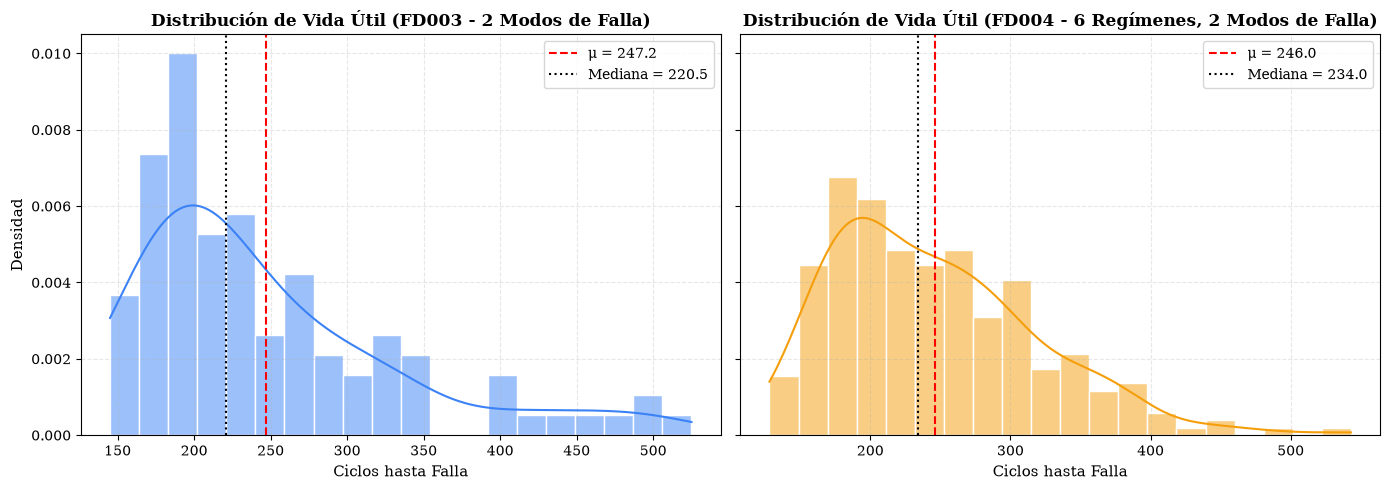

In [4]:
# 4. Gráfica comparativa de distribución de vida útil: FD003 vs FD004
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.histplot(life_fd003, kde=True, ax=axes[0], color='#3B82F6', bins=20, edgecolor='white', stat='density')
axes[0].axvline(life_fd003.mean(), color='red', linestyle='--', linewidth=1.5, label=f'μ = {life_fd003.mean():.1f}')
axes[0].axvline(life_fd003.median(), color='black', linestyle=':', linewidth=1.5, label=f'Mediana = {life_fd003.median():.1f}')
axes[0].set_title('Distribución de Vida Útil (FD003 - 2 Modos de Falla)', fontweight='bold')
axes[0].set_xlabel('Ciclos hasta Falla')
axes[0].set_ylabel('Densidad')
axes[0].legend()

sns.histplot(life_fd004, kde=True, ax=axes[1], color='#F59E0B', bins=20, edgecolor='white', stat='density')
axes[1].axvline(life_fd004.mean(), color='red', linestyle='--', linewidth=1.5, label=f'μ = {life_fd004.mean():.1f}')
axes[1].axvline(life_fd004.median(), color='black', linestyle=':', linewidth=1.5, label=f'Mediana = {life_fd004.median():.1f}')
axes[1].set_title('Distribución de Vida Útil (FD004 - 6 Regímenes, 2 Modos de Falla)', fontweight='bold')
axes[1].set_xlabel('Ciclos hasta Falla')
axes[1].legend()

plt.tight_layout()
guardar_fig('01_distribucion_vida_util_FD004', fig)
plt.show()

---

## 3. Identificación y Cuantización del Espacio Operativo (6 Regímenes)

### Fundamentación Física y Matemática
Las variables de ajuste del C-MAPSS (`setting_1`: Altitud en kft, `setting_2`: Número de Mach, `setting_3`: Throttle Resolver Angle en %) fijan las condiciones termodinámicas de entrada al motor. En FD004, estas condiciones no varían de forma arbitraria, sino que se conmutan estocásticamente entre **6 regímenes operacionales discretos** con perturbaciones de medición gaussiana.

Para desacoplar el efecto de vuelo de la degradación endógena, es indispensable cuantizar el espacio tridimensional mediante **K-Means clustering ($K=6$)**, asignando a cada ciclo $t$ una etiqueta de régimen $R_k \in \{0, 1, 2, 3, 4, 5\}$.

In [5]:
# 1. Normalización y K-Means (K=6) sobre las variables de configuración
scaler_settings = StandardScaler()
settings_scaled = scaler_settings.fit_transform(df_train[SETTING_COLS])

kmeans_regimes = KMeans(n_clusters=6, random_state=42, n_init=10)
df_train['regime'] = kmeans_regimes.fit_predict(settings_scaled)

# 2. Desescalado de centroides para recuperar unidades de ingeniería
centroids_phys = scaler_settings.inverse_transform(kmeans_regimes.cluster_centers_)
df_centroids = pd.DataFrame(centroids_phys, columns=['Altitud (kft)', 'Mach', 'TRA (%)'])
df_centroids['Registros Totales'] = [int((df_train['regime'] == i).sum()) for i in range(6)]
df_centroids['Porcentaje (%)'] = (df_centroids['Registros Totales'] / len(df_train) * 100).round(2)

# Identificación física de cada régimen según la envolvente de vuelo
flight_descriptions = {
    0: 'Crucero Alta Altitud (42 kft, Mach 0.84, TRA 100)',
    1: 'Baja Altitud / Ascenso (10 kft, Mach 0.25, TRA 100)',
    2: 'Descenso / Potencia Reducida (25 kft, Mach 0.62, TRA 60)',
    3: 'Media Altitud / Transición (20 kft, Mach 0.70, TRA 100)',
    4: 'Nivel del Mar / Despegue y Carrete (0 kft, Mach 0.00, TRA 100)',
    5: 'Crucero Alta Altitud (35 kft, Mach 0.84, TRA 100)'
}
df_centroids['Descripción Operativa'] = [flight_descriptions[i] for i in range(6)]
df_centroids.index = [f'Régimen {i}' for i in range(6)]

# Etiqueta legible en el dataset
df_train['regime_name'] = df_train['regime'].map(lambda x: f'Régimen {x}')

print('=== CENTROIDES OPERATIVOS Y CUANTIZACIÓN DE REGÍMENES (FD004) ===')
display(df_centroids.round(2))

=== CENTROIDES OPERATIVOS Y CUANTIZACIÓN DE REGÍMENES (FD004) ===


,Altitud (kft),Mach,TRA (%),Registros Totales,Porcentaje (%),Descripción Operativa
Régimen 0,42.0,0.84,100.0,15395,25.14,"Crucero Alta Altitud (42 kft, Mach 0.84, TRA 100)"
Régimen 1,10.0,0.25,100.0,9224,15.06,"Baja Altitud / Ascenso (10 kft, Mach 0.25, TRA..."
Régimen 2,25.0,0.62,60.0,9139,14.92,"Descenso / Potencia Reducida (25 kft, Mach 0.6..."
Régimen 3,20.0,0.70,100.0,9091,14.84,"Media Altitud / Transición (20 kft, Mach 0.70,..."
Régimen 4,0.0,0.00,100.0,9238,15.08,"Nivel del Mar / Despegue y Carrete (0 kft, Mac..."
Régimen 5,35.0,0.84,100.0,9162,14.96,"Crucero Alta Altitud (35 kft, Mach 0.84, TRA 100)"


  Guardado: notebooks/figures/FD004/02_espacio_operativo_6_regimenes_FD004.png (+ .pdf)


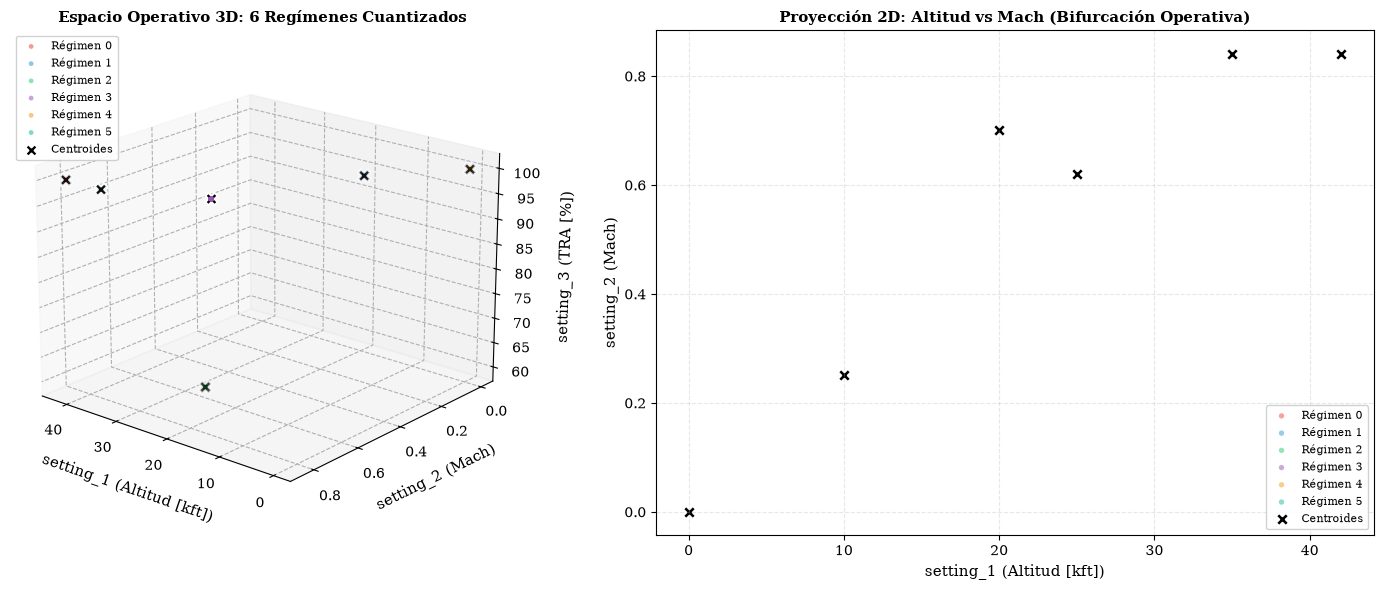

In [6]:
# 3. Visualización del Espacio Operativo: Dispersión 3D y Proyección 2D
fig = plt.figure(figsize=(15, 6))

# Submuestreo estratificado para renderizado fluido y nítido
df_sample = df_train.sample(n=min(5000, len(df_train)), random_state=42).copy()
regime_palette = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6', '#F39C12', '#1ABC9C']

# Panel 1: Dispersión 3D en el espacio de settings
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
for r in range(6):
    mask = df_sample['regime'] == r
    ax1.scatter(
        df_sample.loc[mask, 'setting_1'],
        df_sample.loc[mask, 'setting_2'],
        df_sample.loc[mask, 'setting_3'],
        c=regime_palette[r],
        label=f'Régimen {r}',
        alpha=0.55,
        s=12,
        edgecolor='none'
    )

# Marcar centroides físicos
ax1.scatter(
    centroids_phys[:, 0], centroids_phys[:, 1], centroids_phys[:, 2],
    c='black', s=80, marker='X', edgecolor='white', linewidth=1.5, label='Centroides'
)
ax1.set_xlabel('setting_1 (Altitud [kft])', labelpad=8)
ax1.set_ylabel('setting_2 (Mach)', labelpad=8)
ax1.set_zlabel('setting_3 (TRA [%])', labelpad=8)
ax1.set_title('Espacio Operativo 3D: 6 Regímenes Cuantizados', fontweight='bold', fontsize=11)
ax1.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax1.view_init(elev=20, azim=130)

# Panel 2: Proyección 2D Altitud vs Mach (evidencia de la separación neta)
ax2 = fig.add_subplot(1, 2, 2)
for r in range(6):
    mask = df_sample['regime'] == r
    ax2.scatter(
        df_sample.loc[mask, 'setting_1'],
        df_sample.loc[mask, 'setting_2'],
        c=regime_palette[r],
        label=f'Régimen {r}',
        alpha=0.5,
        s=15,
        edgecolor='none'
    )
ax2.scatter(
    centroids_phys[:, 0], centroids_phys[:, 1],
    c='black', s=90, marker='X', edgecolor='white', linewidth=1.5, label='Centroides'
)
ax2.set_xlabel('setting_1 (Altitud [kft])')
ax2.set_ylabel('setting_2 (Mach)')
ax2.set_title('Proyección 2D: Altitud vs Mach (Bifurcación Operativa)', fontweight='bold', fontsize=11)
ax2.legend(loc='lower right', fontsize=8, framealpha=0.9)

plt.tight_layout()
guardar_fig('02_espacio_operativo_6_regimenes_FD004', fig)
plt.show()

---

## 4. Filtrado de Sensores e Invariancia Condicionada por Régimen

### Fundamentación Metodológica: Varianza Exógena vs. Varianza Endógena
En un escenario multirégimen, evaluar la varianza global $\sigma^2_{\text{global}}$ sobre los datos crudos induce a **falsos positivos de variabilidad**. Un sensor cuyas lecturas dependen de la altitud o de las condiciones de entrada (e.g. $T_2$ o $P_2$) exhibirá una varianza global elevada. No obstante, al evaluar su dispersión dentro de cada régimen operativo $\sigma^2_{\text{intra}}$, si su varianza es nula, el sensor es **estático** y carece de información predictiva de degradación.

Definimos la **Reducción Porcentual de Varianza**:
$$\text{Reducción (\%)} = \left(1 - \frac{\sigma^2_{\text{intra}}}{\sigma^2_{\text{global}}}\right) \times 100$$
y el **Rango Relativo Adimensional** intra-régimen:
$$r_{\text{rel}} = \frac{\max(s) - \min(s)}{\mu(s)} \times 100$$

In [7]:
# 1. Cálculo de varianza global vs intra-régimen media
var_global = df_train[SENSOR_COLS].var()
var_intra = df_train.groupby('regime')[SENSOR_COLS].var().mean()

# 2. Cálculo del rango relativo intra-régimen medio
def calc_r_rel_mean(df_subset, cols):
    r_rels = []
    for r in range(6):
        df_r = df_subset[df_subset['regime'] == r]
        ranges = (df_r[cols].max() - df_r[cols].min()) / df_r[cols].mean().abs() * 100
        r_rels.append(ranges)
    return pd.concat(r_rels, axis=1).mean(axis=1)

r_rel_intra = calc_r_rel_mean(df_train, SENSOR_COLS)

# Nombres y descripciones físicas oficiales C-MAPSS
sensor_names_full = {
    'sensor_1': 'T2 - Temp Total Entrada Fan',
    'sensor_2': 'T24 - Temp Total Salida LPC',
    'sensor_3': 'T30 - Temp Total Salida HPC',
    'sensor_4': 'T50 - Temp Total Salida LPT',
    'sensor_5': 'P2 - Presión Total Entrada Fan',
    'sensor_6': 'P15 - Presión Total Bypass',
    'sensor_7': 'P30 - Presión Total Salida HPC',
    'sensor_8': 'Nf - Velocidad Física Fan',
    'sensor_9': 'Nc - Velocidad Física Core',
    'sensor_10': 'epr - Relación Presión Motor',
    'sensor_11': 'Ps30 - Presión Estática Salida HPC',
    'sensor_12': 'phi - Flujo Combustible / Ps30',
    'sensor_13': 'Nf_dmd - Velocidad Corregida Fan',
    'sensor_14': 'Nc_dmd - Velocidad Corregida Core',
    'sensor_15': 'BPR - Relación Bypass (BPR)',
    'sensor_16': 'far - Relación Quemador Aire/Comb',
    'sensor_17': 'htBleed - Entalpía Purga',
    'sensor_18': 'Nf_dmd - Demanda Velocidad Fan',
    'sensor_19': 'PCNfR_dmd - Demanda Corregida Fan',
    'sensor_20': 'W31 - Purga Refrigerante HPT',
    'sensor_21': 'W32 - Purga Refrigerante LPT'
}

df_variance_analysis = pd.DataFrame({
    'Descripción Física': [sensor_names_full[s] for s in SENSOR_COLS],
    'Varianza Global': var_global,
    'Varianza Intra-Régimen': var_intra,
    'Reducción (%)': ((1 - var_intra / var_global) * 100).round(2),
    'r_rel Intra (%)': r_rel_intra.round(3)
})

# Criterio formal de descarte: Varianza intra < 1e-3 o r_rel < 0.05%
df_variance_analysis['Veredicto'] = np.where(
    (df_variance_analysis['Varianza Intra-Régimen'] < 1e-3) | (df_variance_analysis['r_rel Intra (%)'] < 0.05),
    'Descartar (Invariante)',
    'Conservar (Informativo)'
)

sensors_to_remove = df_variance_analysis[df_variance_analysis['Veredicto'] == 'Descartar (Invariante)'].index.tolist()
sensors_informative = df_variance_analysis[df_variance_analysis['Veredicto'] == 'Conservar (Informativo)'].index.tolist()

print(f'Sensores identificados como invariantes ({len(sensors_to_remove)}): {sensors_to_remove}')
print(f'Sensores informativos retenidos ({len(sensors_informative)}): {sensors_informative}')
display(df_variance_analysis.sort_values('Varianza Intra-Régimen', ascending=True))


Sensores identificados como invariantes (7): ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Sensores informativos retenidos (14): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


,Descripción Física,Varianza Global,Varianza Intra-Régimen,Reducción (%),r_rel Intra (%),Veredicto
sensor_1,T2 - Temp Total Entrada Fan,698.906067,0.000000,100.00,0.000,Descartar (Invariante)
sensor_5,P2 - Presión Total Entrada Fan,13.125202,0.000000,100.00,0.000,Descartar (Invariante)
sensor_19,PCNfR_dmd - Demanda Corregida Fan,28.830710,0.000000,100.00,0.000,Descartar (Invariante)
sensor_18,Nf_dmd - Demanda Velocidad Fan,21162.245693,0.000000,100.00,0.000,Descartar (Invariante)
sensor_16,far - Relación Quemador Aire/Comb,0.000022,0.000002,89.71,13.269,Descartar (Invariante)
sensor_10,epr - Relación Presión Motor,0.016302,0.000025,99.84,3.229,Descartar (Invariante)
sensor_6,P15 - Presión Total Bypass,29.637316,0.000235,100.00,0.617,Descartar (Invariante)
sensor_15,BPR - Relación Bypass (BPR),0.563061,0.004521,99.20,4.718,Conservar (Informativo)
sensor_21,W32 - Purga Refrigerante LPT,35.553759,0.010787,99.97,6.191,Conservar (Informativo)
sensor_20,W31 - Purga Refrigerante HPT,98.731968,0.030051,99.97,6.335,Conservar (Informativo)


  Guardado: notebooks/figures/FD004/03_filtrado_sensores_invariantes_FD004.png (+ .pdf)


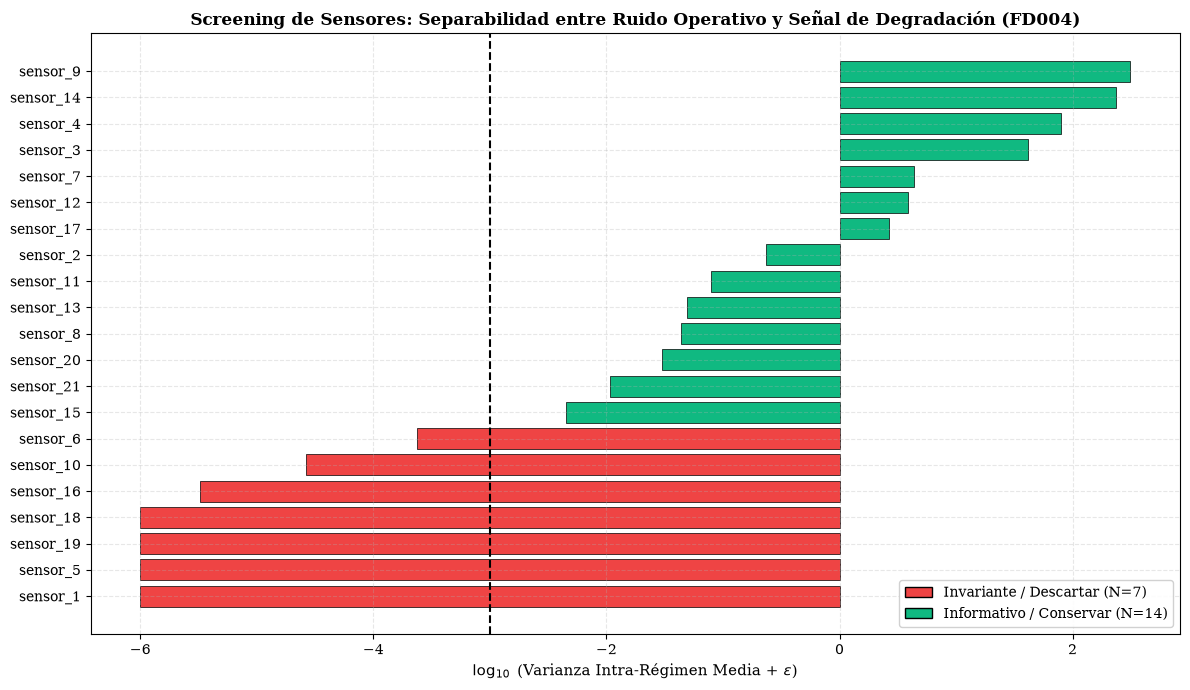

In [8]:
# 3. Gráfica de Varianza Intra-Régimen y Criterio de Exclusión
fig, ax = plt.subplots(figsize=(12, 7))

df_plot = df_variance_analysis.sort_values('Varianza Intra-Régimen', ascending=True)
colors = ['#EF4444' if v == 'Descartar (Invariante)' else '#10B981' for v in df_plot['Veredicto']]

bars = ax.barh(df_plot.index, np.log10(df_plot['Varianza Intra-Régimen'] + 1e-6), color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(np.log10(1e-3), color='black', linestyle='--', linewidth=1.5, label='Umbral de Invariancia ($10^{-3}$)')

ax.set_xlabel(r'$\log_{10}$ (Varianza Intra-Régimen Media + $\epsilon$)', fontsize=11)
ax.set_title('Screening de Sensores: Separabilidad entre Ruido Operativo y Señal de Degradación (FD004)', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--', axis='x')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#EF4444', edgecolor='black', label=f'Invariante / Descartar (N={len(sensors_to_remove)})'),
    Patch(facecolor='#10B981', edgecolor='black', label=f'Informativo / Conservar (N={len(sensors_informative)})')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, framealpha=0.9)

plt.tight_layout()
guardar_fig('03_filtrado_sensores_invariantes_FD004', fig)
plt.show()

---

## 5. Aislamiento de Modos de Falla y Demostración de Pérdida de Identificabilidad

### Fundamentación Metodológica del Desacoplamiento
En FD004 coexisten dos modos de degradación física:
* **Modo 1:** Degradación exclusiva en el Compresor de Alta Presión (*HPC Degradation*).
* **Modo 2:** Degradación combinada en el Compresor de Alta Presión y en el Fan (*HPC + Fan Degradation*).

#### La Trampa del Clustering Crudo:
El régimen de vuelo conmuta ciclo a ciclo, pero el **modo de falla es una propiedad intrínseca e inmutable de cada motor**. Si se aplica clustering directamente sobre los ciclos terminales sin controlar el régimen, la varianza de altitud (que altera lecturas en 30-50%) devora la señal de falla (2-5%), agrupando motores por altitud en vez de por daño físico.

#### Metodología en Dos Fases:
* **Fase A (Aislamiento Condicionado a Régimen Constante):** Extraer la ventana terminal ($RUL \le 35$ ciclos) de cada uno de los 249 motores evaluando **únicamente las muestras del Régimen de Referencia a Nivel del Mar (Alt=0, Mach=0, TRA=100)**, donde la densidad del aire y la máxima demanda mecánica magnifican la divergencia termodinámica entre fallas de HPC y Fan. Se aplica PCA y clustering K-Means ($K=2$) a nivel motor.
* **Fase B (Demostración Visual del Traslape):** Comparar la trayectoria temporal en el régimen controlado (divergencia bimodal limpia) frente a los datos crudos multirégimen (colapso de identificabilidad lineal).

In [9]:
# 1. Cálculo de RUL por motor
max_cycles = df_train.groupby('unit_number')['time_cycles'].max()
df_train['max_cycle'] = df_train['unit_number'].map(max_cycles)
df_train['RUL'] = df_train['max_cycle'] - df_train['time_cycles']

# 2. Selección del Régimen de Referencia (Nivel del Mar: Alt≈0, Mach=0, TRA=100)
# El centroide de K-Means es flotante (≈0.0015, no exactamente 0) → se selecciona el de menor altitud
ref_regime = int(df_centroids['Altitud (kft)'].idxmin().split()[-1])
print(f'Régimen de Referencia seleccionado para aislamiento: Régimen {ref_regime}')

# 3. Filtrar ventana terminal (RUL <= 35) estrictamente en el régimen de referencia
terminal_ref = df_train[(df_train['RUL'] <= 35) & (df_train['regime'] == ref_regime)]
assert terminal_ref['unit_number'].nunique() == 249, 'Alerta: No todos los motores cuentan con ciclos en el régimen de referencia.'

# Vector medio terminal por motor en régimen de referencia
df_terminal_features = terminal_ref.groupby('unit_number')[sensors_informative].mean()

# 4. Estandarización, PCA y K-Means (K=2) a nivel motor
scaler_terminal = StandardScaler()
X_terminal_scaled = scaler_terminal.fit_transform(df_terminal_features)

pca_terminal = PCA(n_components=3, random_state=42)
X_pca_3d = pca_terminal.fit_transform(X_terminal_scaled)
var_exp = pca_terminal.explained_variance_ratio_

kmeans_modes = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans_modes.fit_predict(X_pca_3d)

# Métricas cuantitativas de separabilidad
sil_score = silhouette_score(X_pca_3d, cluster_labels)
db_score = davies_bouldin_score(X_pca_3d, cluster_labels)

# Asignar etiquetas fijas a los 249 motores
df_terminal_features['cluster'] = cluster_labels
df_terminal_features['modo_falla'] = df_terminal_features['cluster'].map({0: 'Modo 1 (HPC)', 1: 'Modo 2 (HPC + Fan)'})
engine_mode_map = df_terminal_features['modo_falla'].to_dict()
df_train['modo_falla'] = df_train['unit_number'].map(engine_mode_map)

# Comparación empírica contra clustering crudo (sin controlar régimen)
terminal_raw = df_train[df_train['RUL'] <= 35].groupby('unit_number')[sensors_informative].mean()
X_raw_pca = PCA(n_components=3, random_state=42).fit_transform(StandardScaler().fit_transform(terminal_raw))
sil_raw = silhouette_score(X_raw_pca, KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_raw_pca))
db_raw = davies_bouldin_score(X_raw_pca, KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_raw_pca))

print('=== VALIDACIÓN CUANTITATIVA DEL AISLAMIENTO DE MODOS DE FALLA ===')
print(f'Varianza Explicada PCA: PC1={var_exp[0]*100:.1f}%, PC2={var_exp[1]*100:.1f}%, PC3={var_exp[2]*100:.1f}% (Total={sum(var_exp)*100:.1f}%)')
print(f'Silhouette Score (Régimen Controlado): {sil_score:.4f}  |  Espacio Crudo: {sil_raw:.4f}')
print(f'Davies-Bouldin   (Régimen Controlado): {db_score:.4f}  |  Espacio Crudo: {db_raw:.4f}')
print('Distribución de motores por modo:', df_terminal_features['modo_falla'].value_counts().to_dict())

Régimen de Referencia seleccionado para aislamiento: Régimen 4
=== VALIDACIÓN CUANTITATIVA DEL AISLAMIENTO DE MODOS DE FALLA ===
Varianza Explicada PCA: PC1=57.9%, PC2=18.8%, PC3=13.0% (Total=89.7%)
Silhouette Score (Régimen Controlado): 0.5975  |  Espacio Crudo: 0.4213
Davies-Bouldin   (Régimen Controlado): 0.6278  |  Espacio Crudo: 0.8619
Distribución de motores por modo: {'Modo 2 (HPC + Fan)': 148, 'Modo 1 (HPC)': 101}


  Guardado: notebooks/figures/FD004/04_pca_clusters_modos_falla_FD004.png (+ .pdf)


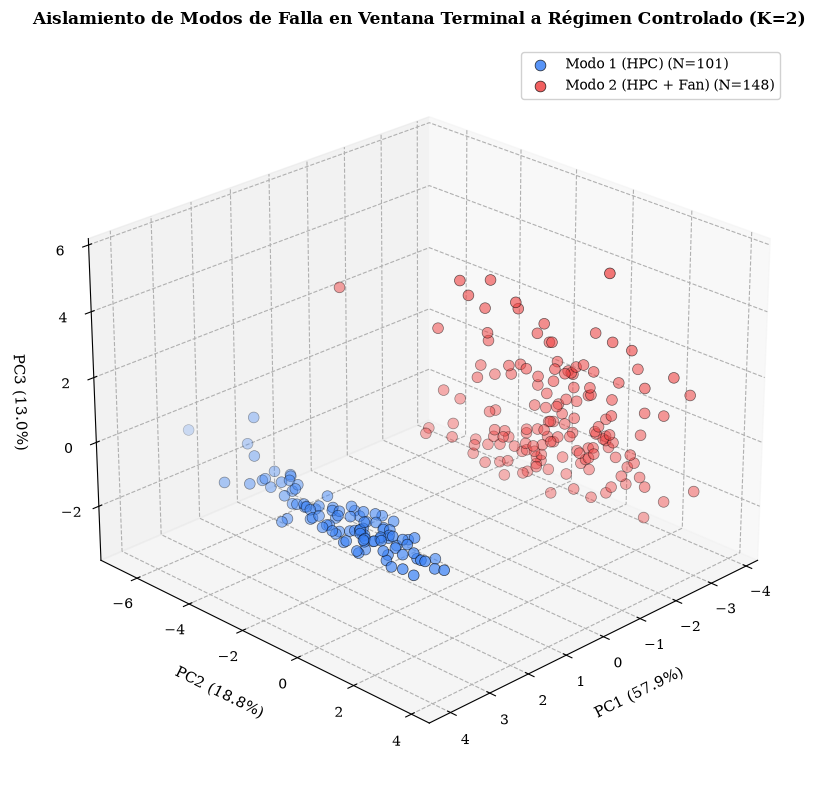

In [10]:
# 5. Visualización PCA 3D de los Modos de Falla Aislados
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

palette_modes = {'Modo 1 (HPC)': '#3B82F6', 'Modo 2 (HPC + Fan)': '#EF4444'}

for mode_name, color in palette_modes.items():
    mask = df_terminal_features['modo_falla'] == mode_name
    ax.scatter(
        X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
        c=color, label=f'{mode_name} (N={mask.sum()})',
        s=60, alpha=0.85, edgecolors='black', linewidth=0.5
    )

ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)', labelpad=10)
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)', labelpad=10)
ax.set_zlabel(f'PC3 ({var_exp[2]*100:.1f}%)', labelpad=10)
ax.set_title('Aislamiento de Modos de Falla en Ventana Terminal a Régimen Controlado (K=2)', fontsize=12, fontweight='bold', pad=15)
ax.legend(loc='upper right', framealpha=0.9)
ax.view_init(elev=25, azim=45)

plt.tight_layout()
guardar_fig('04_pca_clusters_modos_falla_FD004', fig)
plt.show()

  Guardado: notebooks/figures/FD004/05_degradacion_controlada_vs_espacio_crudo_FD004.png (+ .pdf)


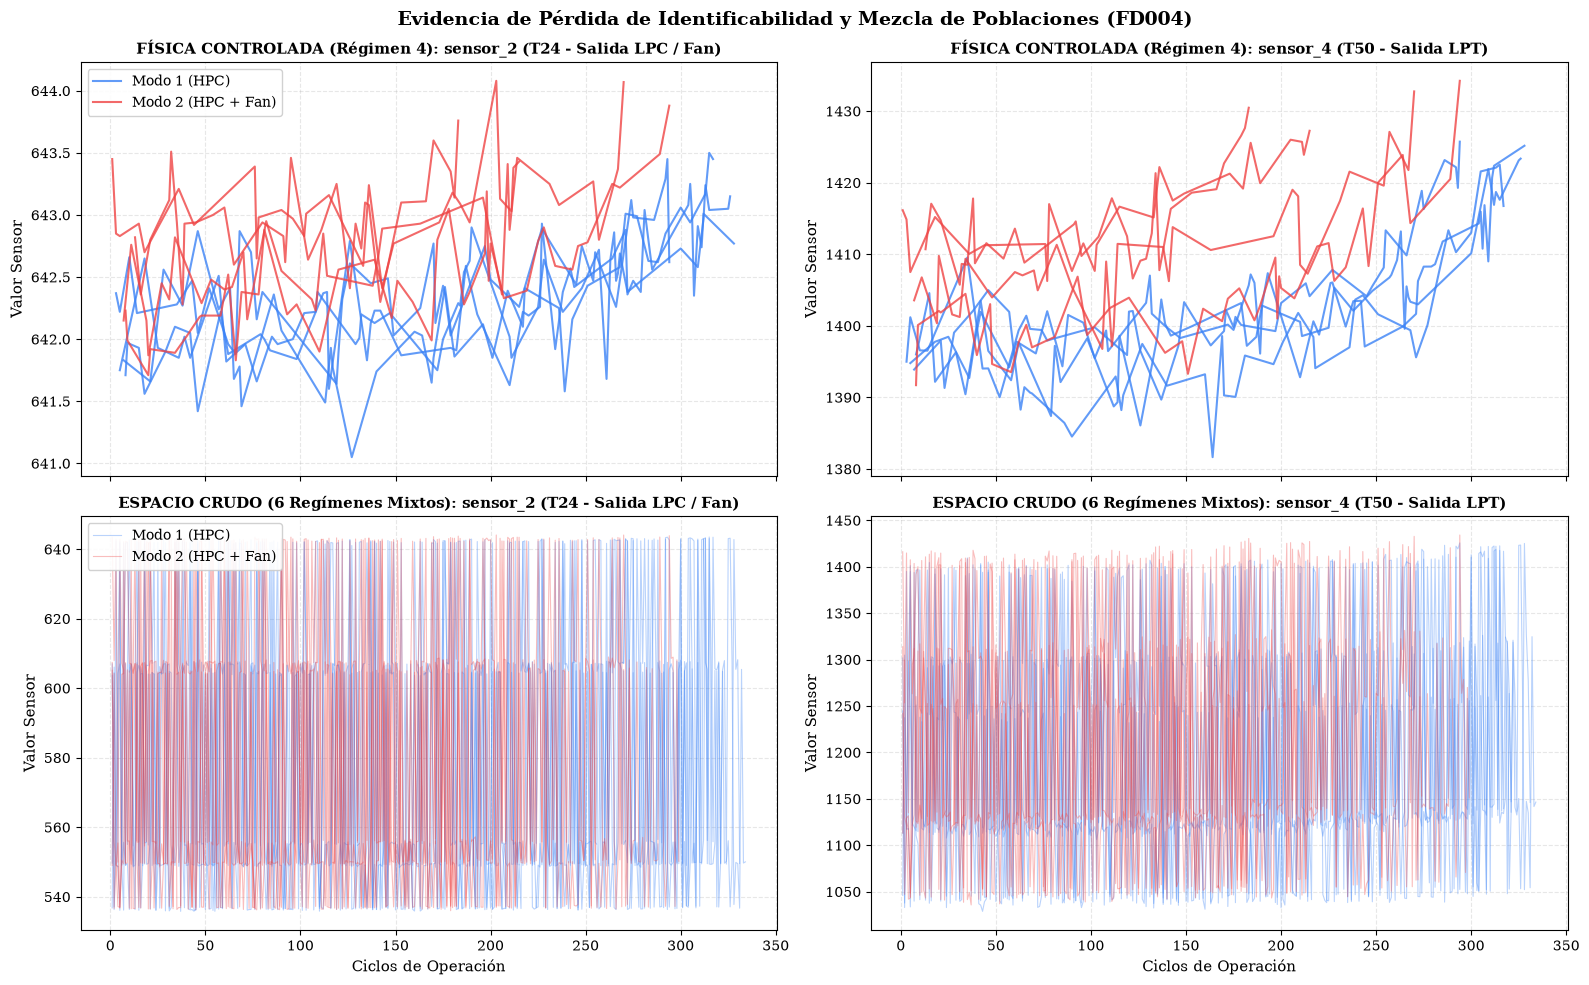

In [11]:
# 6. Demostración Visual del Traslape y Mezcla de Poblaciones (Contraste 2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex='col')

selected_sensors = ['sensor_2', 'sensor_4']
titles = ['sensor_2 (T24 - Salida LPC / Fan)', 'sensor_4 (T50 - Salida LPT)']

# Seleccionar 4 motores representativos de cada modo
engines_m1 = df_terminal_features[df_terminal_features['modo_falla'] == 'Modo 1 (HPC)'].index[:4]
engines_m2 = df_terminal_features[df_terminal_features['modo_falla'] == 'Modo 2 (HPC + Fan)'].index[:4]

# Fila 1: Régimen de Referencia Constante (Física Controlada y Bimodal)
for col_idx, s in enumerate(selected_sensors):
    ax = axes[0, col_idx]
    for u in engines_m1:
        traj = df_train[(df_train['unit_number'] == u) & (df_train['regime'] == ref_regime)]
        ax.plot(traj['time_cycles'], traj[s], color='#3B82F6', alpha=0.8, linewidth=1.5,
                label='Modo 1 (HPC)' if (col_idx == 0 and u == engines_m1[0]) else '')
    for u in engines_m2:
        traj = df_train[(df_train['unit_number'] == u) & (df_train['regime'] == ref_regime)]
        ax.plot(traj['time_cycles'], traj[s], color='#EF4444', alpha=0.8, linewidth=1.5,
                label='Modo 2 (HPC + Fan)' if (col_idx == 0 and u == engines_m2[0]) else '')
    ax.set_title(f'FÍSICA CONTROLADA (Régimen {ref_regime}): {titles[col_idx]}', fontweight='bold', fontsize=11)
    ax.set_ylabel('Valor Sensor')
    ax.grid(True, alpha=0.3, linestyle='--')

axes[0, 0].legend(loc='upper left', fontsize=10, framealpha=0.9)

# Fila 2: Espacio Crudo Multirégimen (Solapamiento y Colapso Lineal)
for col_idx, s in enumerate(selected_sensors):
    ax = axes[1, col_idx]
    for u in engines_m1:
        traj = df_train[df_train['unit_number'] == u]
        ax.plot(traj['time_cycles'], traj[s], color='#3B82F6', alpha=0.35, linewidth=0.8,
                label='Modo 1 (HPC)' if (col_idx == 0 and u == engines_m1[0]) else '')
    for u in engines_m2:
        traj = df_train[df_train['unit_number'] == u]
        ax.plot(traj['time_cycles'], traj[s], color='#EF4444', alpha=0.35, linewidth=0.8,
                label='Modo 2 (HPC + Fan)' if (col_idx == 0 and u == engines_m2[0]) else '')
    ax.set_title(f'ESPACIO CRUDO (6 Regímenes Mixtos): {titles[col_idx]}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Ciclos de Operación')
    ax.set_ylabel('Valor Sensor')
    ax.grid(True, alpha=0.3, linestyle='--')

axes[1, 0].legend(loc='upper left', fontsize=10, framealpha=0.9)

plt.suptitle('Evidencia de Pérdida de Identificabilidad y Mezcla de Poblaciones (FD004)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
guardar_fig('05_degradacion_controlada_vs_espacio_crudo_FD004', fig)
plt.show()

---

## 6. Conclusión Metodológica del EDA y Puente a la Modelación

### 6.1 Síntesis de Hallazgos Empíricos
El análisis exploratorio de datos sobre **FD004** ha establecido con rigor físico y cuantitativo las características estructurales del escenario más complejo de C-MAPSS:

1. **Espacio Operativo Multimodal:** Las condiciones exógenas se agrupan en **6 regímenes operacionales discretos** con alta estabilidad interna.
2. **Filtrado de Sensores Invariantes:** De los 21 sensores, **7 variables** (`sensor_1`, `sensor_5`, `sensor_6`, `sensor_10`, `sensor_16`, `sensor_18`, `sensor_19`) exhiben varianza intra-régimen despreciable ($< 10^{-3}$), evidenciando que su dispersión global es un artefacto espurio de los cambios de altitud y Mach. Su eliminación es obligatoria para reducir dimensionalidad muerta.
3. **Bimodalidad Latente Desacoplada:** Los 249 motores se clasifican de forma consistente en **2 modos de falla dominantes** (HPC vs. HPC+Fan) únicamente cuando se condiciona el análisis a un régimen operativo constante ($Silhouette = 0.60$ vs. $0.42$ en crudo).
4. **Pérdida de Identificabilidad Demostrada:** Al superponer las lecturas de los 6 regímenes, las trayectorias de degradación colapsan en bandas discontinuas cruzadas. Las firmas de falla quedan completamente enmascaradas por el ruido de vuelo.

### 6.2 Justificación del Pipeline Universal y Selector Híbrido
Los hallazgos del EDA invalidan el uso de modelos lineales, umbrales fijos o normalizaciones globales estandarizadas ($Z$-score o MinMax global), ya que violan la premisa de unimodalidad. Queda formalmente fundamentada la necesidad de:

1. **Operating Regime Normalization (ORN):** Estandarización de cada sensor condicionada estrictamente a su clúster de régimen operativo, eliminando la varianza de vuelo sin suprimir la señal de daño.
2. **Generación de Características Temporales por Ventanas Rodantes:** Captura de la cinemática de degradación (medias móviles, desviaciones, pendientes) para restaurar la monotonicidad de la salud del motor.
3. **Selector Híbrido Robusto:** Selección combinada de características basada en *Mutual Information* (lineal y no lineal) y coeficientes de importancia de árboles (*Random Forest / LightGBM*), optimizados mediante búsqueda independiente con **Optuna**.